# 03 — Sepsis Primary Analysis (DR-RF)

Loads experiment results from the checkpoint and generates the **primary manuscript
tables and figures** using DR-RF only.

Sections:
1. Load results
2. Primary results table (ATE MSE + CATE MSE, mean ± 95 % CI)
3. Primary Bar Chart
4. Paired-difference forest plot (CDV_SEPARATE vs each method)
5. CDV support summary
6. Overlap diagnostics
7. Export primary tables

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
REVISED_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [PROJECT_ROOT, REVISED_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(REVISED_ROOT, 'sepsis'))
import config as CFG

from helpers.runner import load_checkpoint
from helpers.metrics import (
    build_primary_table, build_full_learner_table,
    paired_ci, format_ci, resolve_alternative, describe_paired_test,
    build_paper_summary_table, significance_stars,
    METHODS_ORDER, LEARNERS_ORDER
)
from helpers.plotting import (
    plot_primary_bar_table, plot_cdv_support_heatmap, METHOD_LABELS
)

os.makedirs(CFG.PLOTS_DIR, exist_ok=True)
print(f'Setup complete. CI_METHOD={CFG.CI_METHOD!r}, CI_SIDED={CFG.CI_SIDED!r}')


Setup complete. CI_METHOD='bootstrap', CI_SIDED='two-sided'


## 1. Load Results

In [2]:
results_by_seed = load_checkpoint(CFG.CHECKPOINT_PATH)
completed_seeds = sorted(results_by_seed.keys())
print(f'Loaded {len(completed_seeds)} seeds: {completed_seeds}')

if len(completed_seeds) < 5:
    print('WARNING: fewer than 5 seeds. Results will be unreliable.')

Loaded 20 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


## 2. Primary ATE MSE Table (DR-RF)

In [3]:
primary_table = build_primary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
)
print(f'Primary Results Table ({CFG.PRIMARY_LEARNER}) — ATE MSE + CATE MSE')
print(describe_paired_test('method', 'GLOBAL_SENTINEL', 'ATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))
print(describe_paired_test('method', 'GLOBAL_SENTINEL', 'CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))
display(primary_table)


Primary Results Table (DR_RF) — ATE MSE + CATE MSE
paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = method − GLOBAL_SENTINEL  (ATE MSE), paired per outer seed. H1: Δ ≠ 0.
paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = method − GLOBAL_SENTINEL  (CATE MSE), paired per outer seed. H1: Δ ≠ 0.


,Method,ATE MSE (mean),ATE MSE (std),CATE MSE (mean),CATE MSE (std),N seeds,Δ ATE MSE (method − GLOBAL_SENTINEL) [paired mean],Δ ATE MSE paired CI,Δ ATE MSE p-value (paired),Δ CATE MSE (method − GLOBAL_SENTINEL) [paired mean],Δ CATE MSE paired CI,Δ CATE MSE p-value (paired)
0,GLOBAL_SENTINEL,3.384863e+06,3.850227e+06,4.395847e+07,6.225890e+07,20,-,-,-,-,-,-
1,GLOBAL_MISSINGNESS,2.199108e+06,2.037420e+06,2.603699e+08,7.336521e+08,20,-1185754.270481,"[-2333186.3758, -288483.7934]",0.0052,216411470.41609,"[39650451.0517, 543371767.4991]",0.0
2,GLOBAL_MISSINGNESS_CDV,1.651083e+06,1.224574e+06,1.864362e+08,3.581196e+08,20,-1733779.725462,"[-3506786.3390, -458535.2647]",0.0016,142477693.671965,"[48303463.3115, 299289140.6219]",0.0
3,MATCHED_RANDOM_PARTITIONS,2.261983e+06,2.027585e+06,2.603371e+08,7.354037e+08,20,-1122879.808612,"[-2620336.9454, -26708.5618]",0.042,216378642.754634,"[39478876.1343, 543890344.9316]",0.0
4,CDV_SEPARATE,4.039395e+06,5.167375e+06,4.399867e+07,6.349228e+07,20,654532.94867,"[-65217.7425, 1465015.2374]",0.081,40201.129462,"[-2646671.4486, 2789921.8118]",0.9928


## 3. Primary Bar Chart (DR-RF)

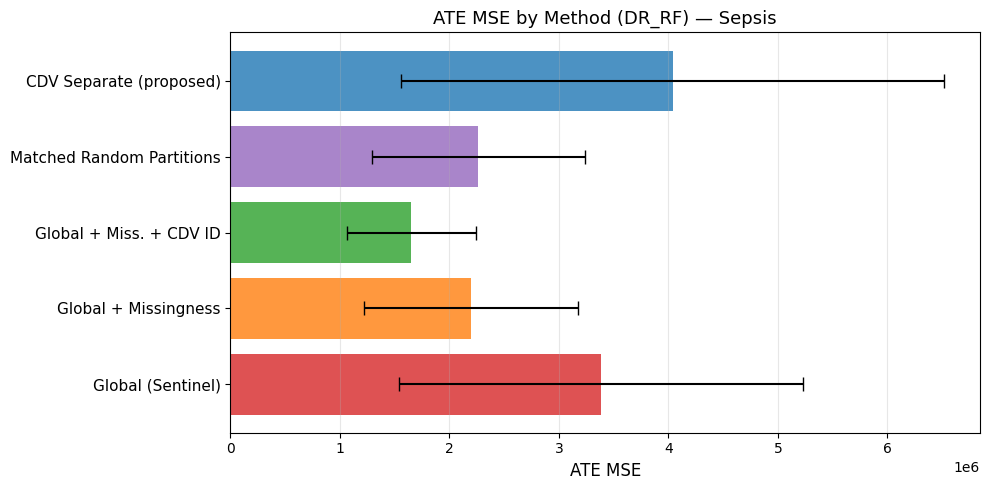

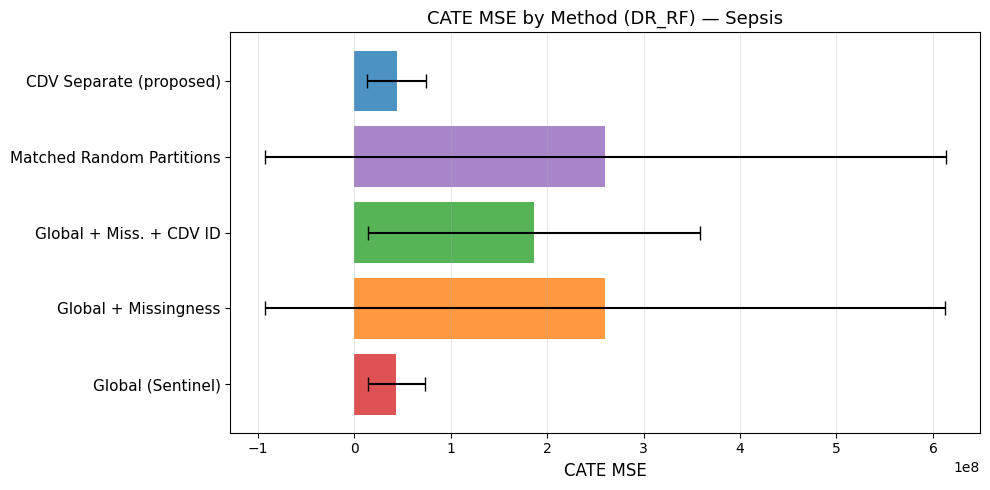

In [4]:
fig = plot_primary_bar_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metric='ate_mse',
    title=f'ATE MSE by Method ({CFG.PRIMARY_LEARNER}) — Sepsis',
    save_path=os.path.join(CFG.PLOTS_DIR, 'primary_ate_mse.png'),
)
plt.show()

fig2 = plot_primary_bar_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metric='cate_mse',
    title=f'CATE MSE by Method ({CFG.PRIMARY_LEARNER}) — Sepsis',
    save_path=os.path.join(CFG.PLOTS_DIR, 'primary_cate_mse.png'),
)
plt.show()

## 3b. Primary Bar Chart — Kendall Tau & Spearman Rho (DR-RF)

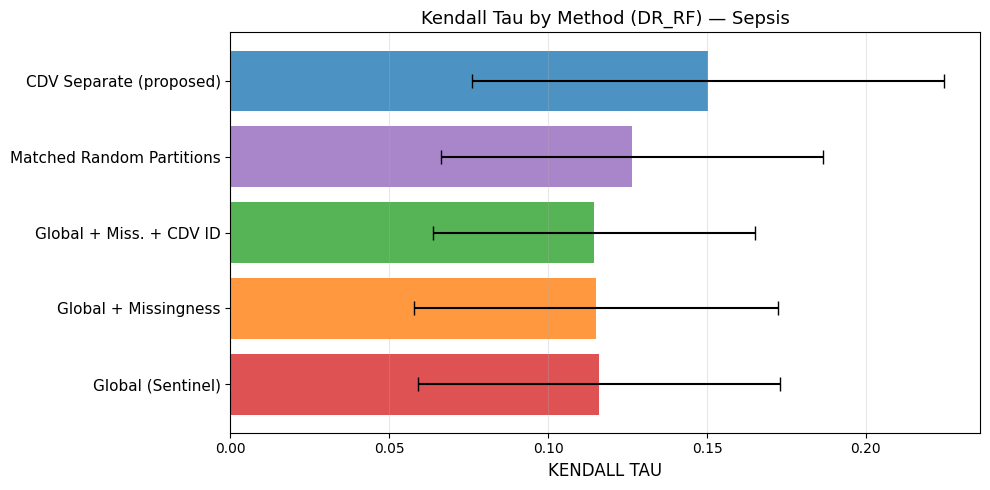

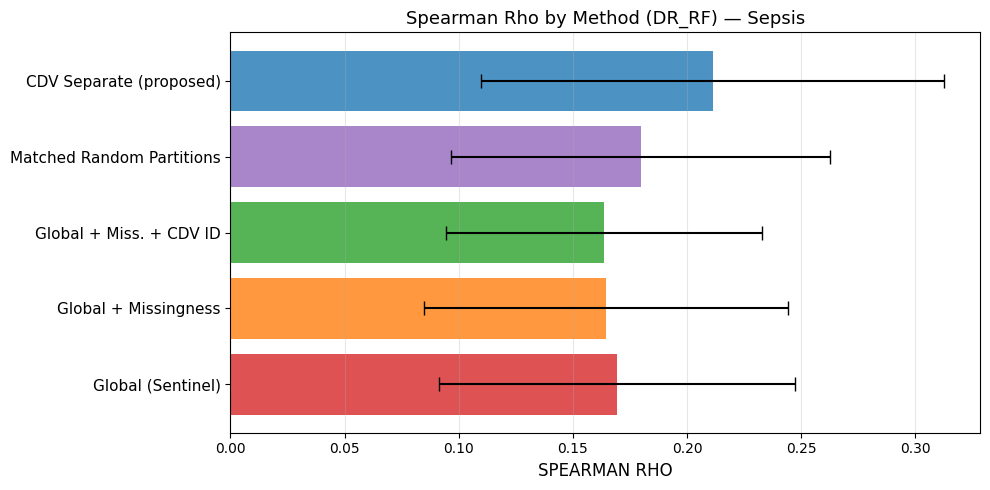

In [5]:
fig3 = plot_primary_bar_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metric='kendall_tau',
    title=f'Kendall Tau by Method ({CFG.PRIMARY_LEARNER}) — Sepsis',
    save_path=os.path.join(CFG.PLOTS_DIR, 'primary_kendall_tau.png'),
)
plt.show()

fig4 = plot_primary_bar_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metric='spearman_rho',
    title=f'Spearman Rho by Method ({CFG.PRIMARY_LEARNER}) — Sepsis',
    save_path=os.path.join(CFG.PLOTS_DIR, 'primary_spearman_rho.png'),
)
plt.show()

## 4. Paired Differences — CDV_SEPARATE vs Each Method

In [6]:
alt_ate = resolve_alternative(CFG.CI_SIDED, lower_is_better=True)
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

cdv_vals = np.array([
    sr['metrics'].get('CDV_SEPARATE', {}).get(CFG.PRIMARY_LEARNER, {}).get('ate_mse', np.nan)
    for sr in results_by_seed.values()
])

paired_ate_rows = [{
    'method': METHOD_LABELS.get('CDV_SEPARATE', 'CDV_SEPARATE'),
    'mean_ate_mse': np.nanmean(cdv_vals),
    'std_ate_mse': np.nanstd(cdv_vals),
    'paired 95% CI of Δ (CDV_SEPARATE − method)': '-',
    'p_value (paired)': '-',
}]
for method in METHODS_ORDER:
    if method == 'CDV_SEPARATE':
        continue
    other_vals = np.array([
        sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('ate_mse', np.nan)
        for sr in results_by_seed.values()
    ])
    res = paired_ci(cdv_vals, other_vals, method=CFG.CI_METHOD, alternative=alt_ate)
    paired_ate_rows.append({
        'method': METHOD_LABELS.get(method, method),
        'mean_ate_mse': np.nanmean(other_vals),
        'std_ate_mse': np.nanstd(other_vals),
        'paired 95% CI of Δ (CDV_SEPARATE − method)': format_ci(res['ci_lo'], res['ci_hi']),
        'p_value (paired)': res['p_value'],
    })

paired_ate_table = pd.DataFrame(paired_ate_rows)
display(paired_ate_table)


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE MSE), paired per outer seed. H1: Δ ≠ 0.


,method,mean_ate_mse,std_ate_mse,paired 95% CI of Δ (CDV_SEPARATE − method),p_value (paired)
0,CDV Separate (proposed),4.039395e+06,5.167375e+06,-,-
1,Global (Sentinel),3.384863e+06,3.850227e+06,"[-65217.7425, 1465015.2374]",0.081
2,Global + Missingness,2.199108e+06,2.037420e+06,"[467162.1411, 3630781.1420]",0.0044
3,Global + Miss. + CDV ID,1.651083e+06,1.224574e+06,"[602973.9811, 4825309.7400]",0.002
4,Matched Random Partitions,2.261983e+06,2.027585e+06,"[267191.5171, 3845272.0495]",0.0134


## 4a. Paired Differences — CDV_SEPARATE vs Each Method (CATE MSE)


In [7]:
alt_cate = resolve_alternative(CFG.CI_SIDED, lower_is_better=True)
print(describe_paired_test('CDV_SEPARATE', 'method', 'CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

cdv_cate_vals = np.array([
    sr['metrics'].get('CDV_SEPARATE', {}).get(CFG.PRIMARY_LEARNER, {}).get('cate_mse', np.nan)
    for sr in results_by_seed.values()
])

paired_cate_rows = [{
    'method': METHOD_LABELS.get('CDV_SEPARATE', 'CDV_SEPARATE'),
    'mean_cate_mse': np.nanmean(cdv_cate_vals),
    'std_cate_mse': np.nanstd(cdv_cate_vals),
    'paired 95% CI of Δ (CDV_SEPARATE − method)': '-',
    'p_value (paired)': '-',
}]
for method in METHODS_ORDER:
    if method == 'CDV_SEPARATE':
        continue
    other_cate_vals = np.array([
        sr['metrics'].get(method, {}).get(CFG.PRIMARY_LEARNER, {}).get('cate_mse', np.nan)
        for sr in results_by_seed.values()
    ])
    res = paired_ci(cdv_cate_vals, other_cate_vals, method=CFG.CI_METHOD, alternative=alt_cate)
    paired_cate_rows.append({
        'method': METHOD_LABELS.get(method, method),
        'mean_cate_mse': np.nanmean(other_cate_vals),
        'std_cate_mse': np.nanstd(other_cate_vals),
        'paired 95% CI of Δ (CDV_SEPARATE − method)': format_ci(res['ci_lo'], res['ci_hi']),
        'p_value (paired)': res['p_value'],
    })

paired_cate_table = pd.DataFrame(paired_cate_rows)
display(paired_cate_table)


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (CATE MSE), paired per outer seed. H1: Δ ≠ 0.


,method,mean_cate_mse,std_cate_mse,paired 95% CI of Δ (CDV_SEPARATE − method),p_value (paired)
0,CDV Separate (proposed),4.399867e+07,6.349228e+07,-,-
1,Global (Sentinel),4.395847e+07,6.225890e+07,"[-2646671.4486, 2789921.8118]",0.9928
2,Global + Missingness,2.603699e+08,7.336521e+08,"[-544022669.2840, -39304514.6515]",0.0
3,Global + Miss. + CDV ID,1.864362e+08,3.581196e+08,"[-298517203.6543, -48137903.1123]",0.0
4,Matched Random Partitions,2.603371e+08,7.354037e+08,"[-544577544.7405, -39344932.5975]",0.0


## 4b. CDV_SEPARATE — Per-Group Metric Breakdown

Breaks ATE MSE and CATE MSE by CDV subgroup (CDV_1, CDV_2, OTHER) to identify
which subgroup drives degradation.  A CDV with high error vs. GLOBAL_SENTINEL
(on the same test subset) is the smoking gun.

In [8]:
from helpers.metrics import ate_mse, cate_mse

LEARNER = CFG.PRIMARY_LEARNER
breakdown_rows = []

for seed, sr in sorted(results_by_seed.items()):
    cdv_pred = sr['predictions'].get('CDV_SEPARATE', {}).get(LEARNER, {})
    glob_pred = sr['predictions'].get('GLOBAL_SENTINEL', {}).get(LEARNER, {})
    ite_pred = cdv_pred.get('ite_pred', np.array([]))
    ite_true = cdv_pred.get('ite_true', np.array([]))
    variant = cdv_pred.get('variant', np.array([]))

    if len(ite_pred) == 0:
        continue

    retained = sr.get('retained_cdv_info', {})
    g_pred = glob_pred.get('ite_pred', np.array([]))
    g_true = glob_pred.get('ite_true', np.array([]))

    for group in sorted(set(variant)):
        mask = variant == group
        n_treated_train = retained.get(group, {}).get('n_treated', np.nan)
        breakdown_rows.append({
            'seed': seed,
            'group': group,
            'n_test': mask.sum(),
            'n_treated_train': n_treated_train,
            'cdv_ate_mse': ate_mse(ite_pred[mask], ite_true[mask]),
            'cdv_cate_mse': cate_mse(ite_pred[mask], ite_true[mask]),
            'global_ate_mse': ate_mse(g_pred[mask], g_true[mask]) if len(g_pred) else np.nan,
            'global_cate_mse': cate_mse(g_pred[mask], g_true[mask]) if len(g_pred) else np.nan,
        })

per_group_breakdown = pd.DataFrame(breakdown_rows)
display(per_group_breakdown)

,seed,group,n_test,n_treated_train,cdv_ate_mse,cdv_cate_mse,global_ate_mse,global_cate_mse
0,0,CDV_1,197,54.0,1.430682e+05,2.008660e+07,9.224392e+05,2.928658e+07
1,0,OTHER,46,NaN,2.677283e+06,3.199567e+07,2.677283e+06,3.199567e+07
2,1,CDV_1,209,41.0,3.035978e+06,1.467400e+07,3.207628e+06,9.390619e+06
3,1,OTHER,34,NaN,3.673258e+06,2.128899e+07,3.673258e+06,2.128899e+07
4,2,CDV_1,201,45.0,1.703140e+06,1.005184e+07,1.948501e+06,1.259526e+07
5,2,OTHER,42,NaN,1.719530e+06,1.828069e+07,1.719530e+06,1.828069e+07
6,3,CDV_1,199,49.0,1.716737e+06,2.032842e+07,9.197088e+05,1.309881e+07
7,3,OTHER,44,NaN,5.553644e+03,2.313601e+07,5.553644e+03,2.313601e+07
8,4,CDV_1,196,45.0,7.770794e+06,5.987699e+07,5.282094e+06,4.637125e+07
9,4,OTHER,47,NaN,3.202448e+06,3.417292e+08,3.202448e+06,3.417292e+08


## 5. CDV Support Summary

In [9]:
# Aggregate per-CDV support statistics across seeds
all_support = []
for seed, sr in results_by_seed.items():
    ss = sr.get('support_stats')
    if isinstance(ss, pd.DataFrame) and not ss.empty:
        ss = ss.copy()
        ss['outer_seed'] = seed
        all_support.append(ss)

if all_support:
    support_df = pd.concat(all_support, ignore_index=True)
    summary = support_df.groupby('cdv_id').agg(
        n_mean=('n', 'mean'), n_std=('n', 'std'),
        n_treated_mean=('n_treated', 'mean'),
        treatment_rate_mean=('treatment_rate', 'mean'),
        overlap_frac_mean=('overlap_fraction', 'mean'),
        ess_mean=('ess', 'mean'),
        seeds_present=('outer_seed', 'nunique'),
    ).round(3)
    print('CDV Support Summary (mean across seeds):')
    display(summary)
    support_df.to_parquet(os.path.join(CFG.ARTIFACTS_DIR, 'support_stats.parquet'), index=False)
    print(f'Saved to: {CFG.ARTIFACTS_DIR}/support_stats.parquet')
else:
    print('No support stats available.')

CDV Support Summary (mean across seeds):


,n_mean,n_std,n_treated_mean,treatment_rate_mean,overlap_frac_mean,ess_mean,seeds_present
cdv_id,,,,,,,
CDV_1,463.25,6.29,43.05,0.093,0.357,52.839,20
OTHER,103.75,6.29,7.95,0.076,0.262,25.878,20


Saved to: cdv_experiments/sepsis/artifacts/support_stats.parquet


## 6. Overlap Diagnostics

In [10]:
if all_support:
    pct_outside = support_df.groupby('cdv_id')['pct_outside_overlap'].mean()
    overlap_summary = pct_outside.round(2).to_frame('pct_outside_overlap_mean')
    display(overlap_summary)

violation_counts = {
    seed: len(sr.get('violations_log', {}))
    for seed, sr in results_by_seed.items()
}
violation_table = (
    pd.Series(violation_counts, name='n_cdv_violations')
    .rename_axis('seed')
    .reset_index()
)
violation_summary = pd.DataFrame([{
    'seeds_with_violations': (violation_table['n_cdv_violations'] > 0).sum(),
    'total_seeds': len(violation_table),
}])
display(violation_table)
display(violation_summary)

,pct_outside_overlap_mean
cdv_id,
CDV_1,64.34
OTHER,73.82


,seed,n_cdv_violations
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,1
6,6,2
7,7,2
8,8,1
9,9,1


,seeds_with_violations,total_seeds
0,20,20


## 7. Export Primary Tables

In [11]:
primary_table.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'primary_results_table.csv'), index=False)
print('Table exported to artifacts/.')

Table exported to artifacts/.


## 8. Paper Summary Table — ATE & CATE MSE

Row index: (Metric, Method) — CDV_SEPARATE is the top row of each metric block
(reference, own raw mean ± std, no CI/significance). Every other method shows
its own raw mean ± std plus the paired 95% CI and significance of
Δ = CDV_SEPARATE − method (see `CFG.CI_METHOD` / `CFG.CI_SIDED`).
Significance: `*` p<0.1, `**` p<0.05, `***` p<0.01, `-` not significant.

In [12]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

ate_cate_summary = build_paper_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
)
display(ate_cate_summary)
ate_cate_summary.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_ate_cate.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.


Mean ± Std  \
Metric   Method                                                       
ATE MSE  CDV Separate (proposed)        4039395.4974 ± 5167375.3159   
         Global (Sentinel)              3384862.5487 ± 3850227.2331   
         Global + Missingness           2199108.2782 ± 2037420.2704   
         Global + Miss. + CDV ID        1651082.8233 ± 1224573.7164   
         Matched Random Partitions      2261982.7401 ± 2027585.3748   
CATE MSE CDV Separate (proposed)      43998674.5357 ± 63492277.6278   
         Global (Sentinel)            43958473.4063 ± 62258896.6485   
         Global + Missingness       260369943.8224 ± 733652063.9993   
         Global + Miss. + CDV ID    186436167.0782 ± 358119601.0101   
         Matched Random Partitions  260337116.1609 ± 735403731.8704   

                                    Paired 95% CI (Δ vs CDV_SEPARATE) Sig.  
Metric   Method                                                             
ATE MSE  CDV Separate (proposed)                                    -    -  
         Global (Sentinel)                [-65217.7425, 1465015.2374]    *  
         Global + Missingness             [467162.1411, 3630781.1420]  ***  
         Global + Miss. + CDV ID          [602973.9811, 4825309.7400]  ***  
         Matched Random Partitions        [267191.5171, 3845272.0495]   **  
CATE MSE CDV Separate (proposed)                                    -    -  
         Global (Sentinel)              [-2646671.4486, 2789921.8118]   ns  
         Global + Missingness       [-544022669.2840, -39304514.6515]  ***  
         Global + Miss. + CDV ID    [-298517203.6543, -48137903.1123]  ***  
         Matched Random Partitions  [-544577544.7405, -39344932.5975]  ***

## 9. Paper Summary Table — Kendall τ & Spearman ρ

Same layout as Section 8, but the primary row key is the ranking metric
(Kendall τ / Spearman ρ, higher is better) and the "Mean ± Std" column shows
each method's own rank-correlation mean ± std (instead of MSE).


In [13]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD))

rank_summary = build_paper_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
)
display(rank_summary)
rank_summary.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_kendall_spearman.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.


Mean ± Std  \
Metric     Method                                       
Kendall τ  CDV Separate (proposed)    0.1504 ± 0.1547   
           Global (Sentinel)          0.1161 ± 0.1186   
           Global + Missingness       0.1151 ± 0.1194   
           Global + Miss. + CDV ID    0.1145 ± 0.1053   
           Matched Random Partitions  0.1263 ± 0.1251   
Spearman ρ CDV Separate (proposed)    0.2113 ± 0.2111   
           Global (Sentinel)          0.1692 ± 0.1622   
           Global + Missingness       0.1645 ± 0.1656   
           Global + Miss. + CDV ID    0.1635 ± 0.1444   
           Matched Random Partitions  0.1796 ± 0.1731   

                                     Paired 95% CI (Δ vs CDV_SEPARATE) Sig.  
Metric     Method                                                            
Kendall τ  CDV Separate (proposed)                                   -    -  
           Global (Sentinel)                          [0.0029, 0.0689]   **  
           Global + Missingness                      [-0.0002, 0.0714]    *  
           Global + Miss. + CDV ID                   [-0.0008, 0.0740]    *  
           Matched Random Partitions                 [-0.0061, 0.0576]   ns  
Spearman ρ CDV Separate (proposed)                                   -    -  
           Global (Sentinel)                          [0.0007, 0.0868]   **  
           Global + Missingness                      [-0.0009, 0.0947]    *  
           Global + Miss. + CDV ID                   [-0.0021, 0.0991]    *  
           Matched Random Partitions                 [-0.0094, 0.0764]   ns

## 10. Compact Signed Summary Tables — ATE/CATE MSE and Kendall τ/Spearman ρ

Two compact tables for the main text (kept separate so error and ranking
metrics never share a paired-test family): rows = method (CDV_SEPARATE
first, reference); columns grouped by metric, each with two sub-columns:
raw **Mean ± Std** and a **signed Δ%** vs CDV_SEPARATE (positive always
means CDV_SEPARATE is better, regardless of metric direction) with
significance stars from a two-sided paired test (see `CFG.CI_METHOD`). This
avoids the earlier issue of a two-sided p-value/CI not directly indicating
*which* method is better.
Significance: `*` p<0.1, `**` p<0.05, `***` p<0.01, `-` not significant.

In [14]:
from helpers.metrics import build_signed_summary_table

print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE',
                            lower_is_better=True, sided='two-sided', ci_method=CFG.CI_METHOD))

signed_summary_ate_cate = build_signed_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
)
display(signed_summary_ate_cate)
signed_summary_ate_cate.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_ate_cate.csv'))

print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ',
                            lower_is_better=False, sided='two-sided', ci_method=CFG.CI_METHOD))

signed_summary_rank = build_signed_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
)
display(signed_summary_rank)
signed_summary_rank.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_kendall_spearman.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.


Metric,ATE MSE,CATE MSE,ATE MSE,CATE MSE
,Mean ± Std,Mean ± Std,Δ% (sig.),Δ% (sig.)
Global (Sentinel),3384862.5487 ± 3850227.2331,43958473.4063 ± 62258896.6485,-19.3%*,-0.1%ns
Global + Missingness,2199108.2782 ± 2037420.2704,260369943.8224 ± 733652063.9993,-83.7%***,+83.1%***
Global + Miss. + CDV ID,1651082.8233 ± 1224573.7164,186436167.0782 ± 358119601.0101,-144.7%***,+76.4%***
Matched Random Partitions,2261982.7401 ± 2027585.3748,260337116.1609 ± 735403731.8704,-78.6%**,+83.1%***
CDV Separate (proposed),4039395.4974 ± 5167375.3159,43998674.5357 ± 63492277.6278,—,—


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.


Metric,Kendall τ,Spearman ρ,Kendall τ,Spearman ρ
,Mean ± Std,Mean ± Std,Δ% (sig.),Δ% (sig.)
Global (Sentinel),0.1161 ± 0.1186,0.1692 ± 0.1622,+29.5%**,+24.8%**
Global + Missingness,0.1151 ± 0.1194,0.1645 ± 0.1656,+30.6%*,+28.5%*
Global + Miss. + CDV ID,0.1145 ± 0.1053,0.1635 ± 0.1444,+31.4%*,+29.2%*
Matched Random Partitions,0.1263 ± 0.1251,0.1796 ± 0.1731,+19.1%ns,+17.6%ns
CDV Separate (proposed),0.1504 ± 0.1547,0.2113 ± 0.2111,—,—


## 11. Multiplicity-Adjusted Summary Tables (FDR-BH correction)

Sections 8–10 each report a **raw, unadjusted** paired p-value per (metric,
method) cell — 4 non-reference methods × up to 2 metrics per table, i.e.
several simultaneous pairwise comparisons — so the raw significance stars
there are optimistic (inflated false-positive rate under multiple testing).
The tables below repeat 8/9/10 with p-values adjusted for multiplicity
across all comparisons **within each table**, using Benjamini-Hochberg
(`adjust_method='fdr_bh'`, controls the false discovery rate; see
`helpers.metrics.adjust_pvalues`). Error metrics (ATE/CATE MSE) and ranking
metrics (Kendall τ/Spearman ρ) form separate FDR families, never pooled
together. Only the significance stars change here — means, CIs, and Δ% are
identical to the unadjusted tables above.

In [15]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE', lower_is_better=True,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD) + '  [stars: FDR-BH adjusted across table]')

ate_cate_summary_fdr = build_paper_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['ate_mse', 'cate_mse'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
    adjust_method='fdr_bh',
)
display(ate_cate_summary_fdr)
ate_cate_summary_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_ate_cate_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted across table]


Mean ± Std  \
Metric   Method                                                       
ATE MSE  CDV Separate (proposed)        4039395.4974 ± 5167375.3159   
         Global (Sentinel)              3384862.5487 ± 3850227.2331   
         Global + Missingness           2199108.2782 ± 2037420.2704   
         Global + Miss. + CDV ID        1651082.8233 ± 1224573.7164   
         Matched Random Partitions      2261982.7401 ± 2027585.3748   
CATE MSE CDV Separate (proposed)      43998674.5357 ± 63492277.6278   
         Global (Sentinel)            43958473.4063 ± 62258896.6485   
         Global + Missingness       260369943.8224 ± 733652063.9993   
         Global + Miss. + CDV ID    186436167.0782 ± 358119601.0101   
         Matched Random Partitions  260337116.1609 ± 735403731.8704   

                                    Paired 95% CI (Δ vs CDV_SEPARATE) Sig.  
Metric   Method                                                             
ATE MSE  CDV Separate (proposed)                                    -    -  
         Global (Sentinel)                [-65217.7425, 1465015.2374]    *  
         Global + Missingness             [467162.1411, 3630781.1420]  ***  
         Global + Miss. + CDV ID          [602973.9811, 4825309.7400]  ***  
         Matched Random Partitions        [267191.5171, 3845272.0495]   **  
CATE MSE CDV Separate (proposed)                                    -    -  
         Global (Sentinel)              [-2646671.4486, 2789921.8118]   ns  
         Global + Missingness       [-544022669.2840, -39304514.6515]  ***  
         Global + Miss. + CDV ID    [-298517203.6543, -48137903.1123]  ***  
         Matched Random Partitions  [-544577544.7405, -39344932.5975]  ***

In [16]:
print(describe_paired_test('CDV_SEPARATE', 'method', 'Kendall τ / Spearman ρ', lower_is_better=False,
                            sided=CFG.CI_SIDED, ci_method=CFG.CI_METHOD) + '  [stars: FDR-BH adjusted across table]')

rank_summary_fdr = build_paper_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['kendall_tau', 'spearman_rho'],
    metric_labels={'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided=CFG.CI_SIDED,
    adjust_method='fdr_bh',
)
display(rank_summary_fdr)
rank_summary_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'paper_summary_kendall_spearman_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted across table]


Mean ± Std  \
Metric     Method                                       
Kendall τ  CDV Separate (proposed)    0.1504 ± 0.1547   
           Global (Sentinel)          0.1161 ± 0.1186   
           Global + Missingness       0.1151 ± 0.1194   
           Global + Miss. + CDV ID    0.1145 ± 0.1053   
           Matched Random Partitions  0.1263 ± 0.1251   
Spearman ρ CDV Separate (proposed)    0.2113 ± 0.2111   
           Global (Sentinel)          0.1692 ± 0.1622   
           Global + Missingness       0.1645 ± 0.1656   
           Global + Miss. + CDV ID    0.1635 ± 0.1444   
           Matched Random Partitions  0.1796 ± 0.1731   

                                     Paired 95% CI (Δ vs CDV_SEPARATE) Sig.  
Metric     Method                                                            
Kendall τ  CDV Separate (proposed)                                   -    -  
           Global (Sentinel)                          [0.0029, 0.0689]    *  
           Global + Missingness                      [-0.0002, 0.0714]    *  
           Global + Miss. + CDV ID                   [-0.0008, 0.0740]    *  
           Matched Random Partitions                 [-0.0061, 0.0576]   ns  
Spearman ρ CDV Separate (proposed)                                   -    -  
           Global (Sentinel)                          [0.0007, 0.0868]    *  
           Global + Missingness                      [-0.0009, 0.0947]    *  
           Global + Miss. + CDV ID                   [-0.0021, 0.0991]    *  
           Matched Random Partitions                 [-0.0094, 0.0764]   ns

In [ ]:
from helpers.metrics import build_signed_summary_table

print(describe_paired_test('CDV_SEPARATE', 'method', 'ATE/CATE MSE / Kendall τ / Spearman ρ',
                            lower_is_better=True, sided='two-sided', ci_method=CFG.CI_METHOD)
      + '  [stars: FDR-BH adjusted, 3 families: ATE MSE alone, CATE MSE alone, Kendall τ + Spearman ρ together]')

signed_summary_fdr = build_signed_summary_table(
    results_by_seed,
    learner=CFG.PRIMARY_LEARNER,
    metrics=['ate_mse', 'cate_mse', 'kendall_tau', 'spearman_rho'],
    metric_labels={'ate_mse': 'ATE MSE', 'cate_mse': 'CATE MSE',
                   'kendall_tau': 'Kendall τ', 'spearman_rho': 'Spearman ρ'},
    method_labels=METHOD_LABELS,
    lower_is_better={'ate_mse': True, 'cate_mse': True, 'kendall_tau': False, 'spearman_rho': False},
    ci_method=CFG.CI_METHOD,
    sided='two-sided',
    adjust_method='fdr_bh',
    metric_families={'kendall_tau': 'RANK', 'spearman_rho': 'RANK'},
)
display(signed_summary_fdr)
signed_summary_fdr.to_csv(os.path.join(CFG.ARTIFACTS_DIR, 'signed_summary_ate_cate_kendall_spearman_fdr_bh.csv'))


paired bootstrap CI (10,000 resamples), two-sided (alpha=0.05). Δ = CDV_SEPARATE − method  (ATE/CATE MSE / Kendall τ / Spearman ρ), paired per outer seed. H1: Δ ≠ 0.  [stars: FDR-BH adjusted, 4 separate families: ATE MSE, CATE MSE, Kendall τ, Spearman ρ]


Metric,ATE MSE,CATE MSE,Kendall τ,Spearman ρ,ATE MSE,CATE MSE,Kendall τ,Spearman ρ
,Mean ± Std,Mean ± Std,Mean ± Std,Mean ± Std,Δ% (sig.),Δ% (sig.),Δ% (sig.),Δ% (sig.)
Global (Sentinel),3384862.5487 ± 3850227.2331,43958473.4063 ± 62258896.6485,0.1161 ± 0.1186,0.1692 ± 0.1622,-19.3%*,-0.1%ns,+29.5%*,+24.8%*
Global + Missingness,2199108.2782 ± 2037420.2704,260369943.8224 ± 733652063.9993,0.1151 ± 0.1194,0.1645 ± 0.1656,-83.7%**,+83.1%***,+30.6%*,+28.5%*
Global + Miss. + CDV ID,1651082.8233 ± 1224573.7164,186436167.0782 ± 358119601.0101,0.1145 ± 0.1053,0.1635 ± 0.1444,-144.7%***,+76.4%***,+31.4%*,+29.2%*
Matched Random Partitions,2261982.7401 ± 2027585.3748,260337116.1609 ± 735403731.8704,0.1263 ± 0.1251,0.1796 ± 0.1731,-78.6%**,+83.1%***,+19.1%ns,+17.6%ns
CDV Separate (proposed),4039395.4974 ± 5167375.3159,43998674.5357 ± 63492277.6278,0.1504 ± 0.1547,0.2113 ± 0.2111,—,—,—,—
